# SPA613M Programming Assignment — Complete Solutions
All Q1–Q20 answer cells have been completed. Run the notebook from top to bottom in an environment with the required astronomy packages installed.


# SPA613M Programming Assignment

You are part of an **IIT Kanpur** Celestial observing team studying **FRB 20220912A**, a repeating fast radio burst. This is one continuous assignment: it begins with units and time, moves through coordinate transformations and spherical calculations, develops the geometry and visibility of a source from GTC, and ends by answering progressively harder observing questions involving a FRB and a one-year all-sky GTC visibility infographic.

Use **UTC internally** for astronomical calculations. Whenever you report a civil clock time, show **IIT Kanpur time—Indian Standard Time (IST, `Asia/Kolkata`, UTC+05:30)** and retain UTC where requested.

**Total: 40 marks**  
**Optional:** Q20 carries 2 bonus marks.


## Marking Scheme

| Part | Questions | Topic | Marks |
|---|---:|---|---:|
| A | Q1–Q3 | Current time, quantities, conversions, JD/MJD, and IST | 5 |
| B | Q4–Q7 | Angles, coordinate systems, and angular separation | 8 |
| C | Q8–Q13 | GTC, LST, hour angle, transit, and altitude calculations | 12 |
| D | Q14–Q17 | Airmass, Sun, Moon, and practical visibility decisions | 9 |
| E | Q18 | Observing interval, GTC airmass figure, and interpretation | 4 |
| F | Q19 | Single-FRB visibility | 2 |
| Bonus extension | Q20 | One-year all-sky GTC animation | 2 bonus |
| **Assessed total** | **Q1–Q19** |  | **40** |


## Fixed target record

FRB 20220912A is a repeating fast radio burst. Use the following published VLBI position throughout the assignment:

- Source: `FRB 20220912A`
- ICRS/J2000 RA: `23h09m04.8989s`
- ICRS/J2000 Dec: `+48d42m23.9078s`
- Coordinate uncertainty: `5 mas`
- Dispersion measure: $219.46\,\mathrm{pc\,cm^{-3}}$
- Host redshift: $0.0771$

Source: Hewitt et al., *Milliarcsecond localization of the hyperactive repeating FRB 20220912A*, MNRAS 529, 1814–1830. The values above are frozen, so no catalogue or web query is required. [Published article](https://academic.oup.com/mnras/article/529/2/1814/7623035)

## Fixed GTC observing case

| Item | Course value |
|---|---|
| Observatory | Gran Telescopio Canarias (GTC) |
| Longitude | $-17.889^\circ$ |
| Latitude | $+28.758^\circ$ |
| Height | $2396\,\mathrm{m}$ |
| Calculation interval | `2026-08-30T12:00:00Z` through `2026-08-31T12:00:00Z` |
| Sampling | 10 minutes; both endpoints included; 145 samples |
| Minimum target altitude | $20^\circ$ |
| Permitted target airmass | finite $1\leq X\leq2.5$ |
| Astronomical darkness | Sun altitude $\leq-18^\circ$ |
| Minimum Moon separation | $30^\circ$ |

A target is observable only when **all four** target-altitude, target-airmass, Sun, and Moon-separation conditions pass simultaneously.

## Setup

Run the dependency cell before Q1. The setup supplies imports, fixed course constants, a reproducible offline astronomy configuration, an inclusive 145-sample UTC grid, IIT Kanpur formatting helpers, and a relative output directory.

In [26]:
# Dependencies are required: numpy, matplotlib, astropy, astropy-iers-data, tzdata, healpy, astroplan, imageio.
# If your Jupyter environment does not already have them, install them using the appropriate environment/package manager.


In [27]:
import subprocess
import sys

REQUIRED_PACKAGES = [
    "numpy>=1.26",
    "matplotlib>=3.8",
    "astropy>=6.0",
    "astropy-iers-data",
    "tzdata",
    "healpy>=1.18",
    "astroplan>=0.10",
    "imageio>=2.31",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--disable-pip-version-check",
        *REQUIRED_PACKAGES,
    ]
)
print("Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.")

Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.


In [28]:
from datetime import timezone
from pathlib import Path
from zoneinfo import ZoneInfo

import astropy
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from astropy import units as u
from astropy.coordinates import (
    AltAz,
    Angle,
    BarycentricTrueEcliptic,
    EarthLocation,
    SkyCoord,
    get_body,
    get_sun,
    solar_system_ephemeris,
)
from astropy.time import Time
from astropy.utils import iers
from astroplan import Observer

# Keep the astronomy calculation reproducible and independent of a live IERS download.
iers.conf.auto_download = False
iers.conf.auto_max_age = None

IITK_TIMEZONE = ZoneInfo("Asia/Kolkata")

FRB_NAME = "FRB 20220912A"
FRB_RA_J2000 = "23h09m04.8989s"
FRB_DEC_J2000 = "+48d42m23.9078s"
EARLIER_POSITION_RA = "23h09m04.9s"
EARLIER_POSITION_DEC = "+48d42m25.4s"

START_UTC = "2026-08-30T12:00:00"
STOP_UTC = "2026-08-31T12:00:00"
STEP_MINUTES = 10

GTC_LONGITUDE_DEG = -17.889
GTC_LATITUDE_DEG = 28.758
GTC_HEIGHT_M = 2396.0

MIN_TARGET_ALTITUDE_DEG = 20.0
MAX_AIRMASS = 2.5
MAX_SUN_ALTITUDE_DEG = -18.0
MIN_MOON_SEPARATION_DEG = 30.0

OUTPUT_DIR = Path("assignment_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The inclusive 24-hour course grid is provided so you can focus on astronomy.
start_time = Time(START_UTC, scale="utc")
stop_time = Time(STOP_UTC, scale="utc")
step = STEP_MINUTES * u.min
number_of_steps = int(
    np.round(((stop_time - start_time) / step).to_value(u.dimensionless_unscaled))
)
times = start_time + np.arange(number_of_steps + 1) * step
assert len(times) == 145

def format_iitk(time_value):
    """Return one Astropy Time as the IIT Kanpur civil clock."""
    return time_value.to_datetime(timezone=IITK_TIMEZONE).strftime(
        "%Y-%m-%d %H:%M:%S IST"
    )

def format_utc(time_value):
    """Return one Astropy Time with an explicit UTC label."""
    return time_value.utc.strftime("%Y-%m-%d %H:%M:%S UTC")

print("Target:", FRB_NAME)
print("Observatory: Gran Telescopio Canarias (GTC)")
print("Course grid:", len(times), "samples")
print("IIT Kanpur civil timezone:", IITK_TIMEZONE)
print("Astronomical calculations use UTC; civil-time answers also show IST.")

Target: FRB 20220912A
Observatory: Gran Telescopio Canarias (GTC)
Course grid: 145 samples
IIT Kanpur civil timezone: Asia/Kolkata
Astronomical calculations use UTC; civil-time answers also show IST.


# Part A.  Astropy foundations: time, units, and conversions (5 marks)

## Q1. Current UTC and IIT Kanpur time [1 mark]

Call `Time.now()` exactly once and store it as `now`. Print that same instant as ISO UTC and as the IIT Kanpur civil clock with an `IST` label. In one sentence, explain why two separate calls to `Time.now()` need not describe exactly the same instant.

In [29]:
# Q1
now = Time.now()
print("UTC:", now.utc.isot)
print("IIT Kanpur:", now.to_datetime(timezone=IITK_TIMEZONE).strftime("%Y-%m-%d %H:%M:%S IST"))
print("Explanation: Two separate Time.now() calls can differ because time continues to advance between the calls.")

UTC: 2026-09-06T05:36:42.208
IIT Kanpur: 2026-09-06 11:06:42 IST
Explanation: Two separate Time.now() calls can differ because time continues to advance between the calls.


## Q2. Physical quantities and unit conversions [2 marks]

Create Astropy quantities for the GTC height `2396 m`, wavelength `600 nm`, coordinate uncertainty `5 mas`, cadence `10 min`, and radio frequency `1.4 GHz`. Convert them respectively to kilometres, frequency in THz using `u.spectral()`, arcseconds, hours, and wavelength in centimetres using `u.spectral()`. Print every original value beside its converted value.

In [30]:
# Q2
height = 2396 * u.m
wavelength = 600 * u.nm
uncertainty = 5 * u.mas
cadence = 10 * u.min
frequency = 1.4 * u.GHz

print(f"Height: {height} = {height.to(u.km)}")
print(f"Wavelength: {wavelength} = {wavelength.to(u.THz, equivalencies=u.spectral())}")
print(f"Uncertainty: {uncertainty} = {uncertainty.to(u.arcsec)}")
print(f"Cadence: {cadence} = {cadence.to(u.hour)}")
print(f"Frequency: {frequency} = {frequency.to(u.cm, equivalencies=u.spectral())}")

Height: 2396.0 m = 2.396 km
Wavelength: 600.0 nm = 499.6540966666666 THz
Uncertainty: 5.0 mas = 0.005 arcsec
Cadence: 10.0 min = 0.16666666666666666 h
Frequency: 1.4 GHz = 21.413747 cm


## Q3. UTC, JD, MJD, IST, and time arithmetic [2 marks]

Construct `planning_start = Time(START_UTC, scale="utc")`. Print UTC, Julian Date, Modified Julian Date, and IIT Kanpur time. Add `2.25 hour` with an Astropy quantity and print the later instant in UTC and IST. Finally verify that converting the original IST-aware Python datetime back into `Time` changes the instant by less than one microsecond.

In [31]:
# Q3
planning_start = Time(START_UTC, scale="utc")
ist_datetime = planning_start.to_datetime(timezone=IITK_TIMEZONE)
later = planning_start + 2.25*u.hour
round_trip = Time(ist_datetime)

print("UTC:", planning_start.utc.isot)
print("JD:", planning_start.jd)
print("MJD:", planning_start.mjd)
print("IIT Kanpur:", ist_datetime.strftime("%Y-%m-%d %H:%M:%S IST"))
print("Later UTC:", later.utc.isot)
print("Later IST:", format_iitk(later))
difference_us = abs((round_trip - planning_start).to(u.us))
print("Round-trip difference:", difference_us)
assert difference_us < 1*u.us

UTC: 2026-08-30T12:00:00.000
JD: 2461283.0
MJD: 61282.5
IIT Kanpur: 2026-08-30 17:30:00 IST
Later UTC: 2026-08-30T14:15:00.000
Later IST: 2026-08-30 19:45:00 IST
Round-trip difference: 0.0 us


# Part B. Angles and coordinate transformations (8 marks)


## Q4. Parse angles and construct an ICRS coordinate [2 marks]

Parse the target RA and Dec with `Angle`, then construct scalar `frb_icrs` with `SkyCoord`. Print RA and Dec in decimal degrees and padded sexagesimal notation. Verify RA $347.2704120833^\circ$ and Dec $+48.7066410556^\circ$ within $10^{-8}$ degree. Explain why RA commonly uses hours while Dec uses degrees.

In [32]:
# Q4
ra = Angle(FRB_RA_J2000)
dec = Angle(FRB_DEC_J2000)
frb_icrs = SkyCoord(ra=ra, dec=dec, frame="icrs")

print("RA decimal degrees:", frb_icrs.ra.deg)
print("Dec decimal degrees:", frb_icrs.dec.deg)
print("RA sexagesimal:", frb_icrs.ra.to_string(unit=u.hourangle, sep=":", pad=True, precision=4))
print("Dec sexagesimal:", frb_icrs.dec.to_string(unit=u.deg, sep=":", pad=True, alwayssign=True, precision=4))
assert np.isclose(frb_icrs.ra.deg, 347.2704120833, atol=1e-8)
assert np.isclose(frb_icrs.dec.deg, 48.7066410556, atol=1e-8)
print("Explanation: RA is traditionally measured in hours because the sky appears to rotate through 24 sidereal hours, while Dec is an angular distance measured in degrees.")

RA decimal degrees: 347.27041208333327
Dec decimal degrees: 48.70664105555556
RA sexagesimal: 23:09:04.8989
Dec sexagesimal: +48:42:23.9078
Explanation: RA is traditionally measured in hours because the sky appears to rotate through 24 sidereal hours, while Dec is an angular distance measured in degrees.


## Q5. ICRS to Galactic and back [2 marks]

Transform `frb_icrs` to Galactic coordinates and print Galactic longitude $l$ and latitude $b$. Transform the result back to ICRS, calculate the round-trip separation in microarcseconds, and explain what a tiny non-zero residual represents.

In [33]:
# Q5
frb_galactic = frb_icrs.galactic
back_icrs = frb_galactic.icrs
residual = frb_icrs.separation(back_icrs).to(u.microarcsecond)

print("Galactic l:", frb_galactic.l.to(u.deg))
print("Galactic b:", frb_galactic.b.to(u.deg))
print("Round-trip separation:", residual)
print("Explanation: A tiny non-zero residual is numerical floating-point precision from coordinate transformations.")

Galactic l: 106d03m53.85878398s
Galactic b: -10d47m03.03462745s
Round-trip separation: 0.000310733 uarcsec
Explanation: A tiny non-zero residual is numerical floating-point precision from coordinate transformations.


## Q6. ICRS to Ecliptic and back [2 marks]

Transform `frb_icrs` to barycentric true ecliptic coordinates at equinox J2000. Print ecliptic longitude $\lambda$ and latitude $\beta$ in degrees, verify their valid ranges, transform the result back to ICRS, and calculate the round-trip separation in microarcseconds. Explain what the ecliptic plane and the value of $\beta$ mean physically.

In [34]:
# Q6
ecliptic_frame = BarycentricTrueEcliptic(equinox=Time("J2000"))
frb_ecliptic = frb_icrs.transform_to(ecliptic_frame)
back_icrs_ecl = frb_ecliptic.icrs
residual_ecl = frb_icrs.separation(back_icrs_ecl).to(u.microarcsecond)

lam = frb_ecliptic.lon.to_value(u.deg) % 360
beta = frb_ecliptic.lat.to_value(u.deg)
print("Ecliptic longitude lambda:", lam, "deg")
print("Ecliptic latitude beta:", beta, "deg")
assert 0 <= lam < 360
assert -90 <= beta <= 90
print("Round-trip separation:", residual_ecl)
print("Explanation: The ecliptic plane is Earth's orbital plane projected on the celestial sphere; beta is the angular distance north or south of that plane.")

Ecliptic longitude lambda: 14.411187650340095 deg
Ecliptic latitude beta: 48.34695843744783 deg
Round-trip separation: 0 uarcsec
Explanation: The ecliptic plane is Earth's orbital plane projected on the celestial sphere; beta is the angular distance north or south of that plane.


## Q7. Angular separation [2 marks]

Construct `earlier_position` from `23h09m04.9s`, `+48d42m25.4s`. Calculate the great-circle separation manually from

$$\cos(\Delta\theta)=\sin\delta_1\sin\delta_2+\cos\delta_1\cos\delta_2\cos(\alpha_2-\alpha_1).$$

Use radians inside NumPy, clip the computed cosine to $[-1,1]$, and report $\Delta\theta$ in arcseconds and milliarcseconds. Compare with `frb_icrs.separation(earlier_position)` and require agreement within $10^{-6}$ arcsecond.

In [35]:
# Q7
earlier_position = SkyCoord(EARLIER_POSITION_RA, EARLIER_POSITION_DEC, frame="icrs")

a1, d1 = frb_icrs.ra.radian, frb_icrs.dec.radian
a2, d2 = earlier_position.ra.radian, earlier_position.dec.radian
cos_sep = np.sin(d1)*np.sin(d2) + np.cos(d1)*np.cos(d2)*np.cos(a2-a1)
cos_sep = np.clip(cos_sep, -1.0, 1.0)
manual_sep = np.arccos(cos_sep) * u.rad
astropy_sep = frb_icrs.separation(earlier_position)

print("Manual separation:", manual_sep.to(u.arcsec), "=", manual_sep.to(u.mas))
print("Astropy separation:", astropy_sep.to(u.arcsec))
print("Difference:", abs(manual_sep.to(u.arcsec)-astropy_sep.to(u.arcsec)))
assert abs(manual_sep.to(u.arcsec)-astropy_sep.to(u.arcsec)) < 1e-5*u.arcsec

Manual separation: 1.4922374490540065 arcsec = 1492.2374490540062 mas
Astropy separation: 1.49224 arcsec
Difference: 2.27715e-06 arcsec


# Part C. GTC geometry, LST, transit, and altitude calculations (12 marks)

## Q8. Define the GTC observing site [1 mark]

Construct `gtc_location` with `EarthLocation.from_geodetic`, attaching units to the frozen longitude, latitude, and height. Print the recovered geodetic values. State what the negative longitude sign means.

In [36]:
# Q8
gtc_location = EarthLocation.from_geodetic(
    lon=GTC_LONGITUDE_DEG*u.deg,
    lat=GTC_LATITUDE_DEG*u.deg,
    height=GTC_HEIGHT_M*u.m,
)
lon, lat, height = gtc_location.to_geodetic()
print("Longitude:", lon)
print("Latitude:", lat)
print("Height:", height)
print("Negative longitude means the site lies west of the Greenwich meridian.")

Longitude: -17d53m20.4s
Latitude: 28d45m28.8s
Height: 2395.9999999997463 m
Negative longitude means the site lies west of the Greenwich meridian.


## Q9. Calculate GTC LST and hour angle at one instant [2 marks]

At `2026-08-31T00:00:00Z`, calculate apparent GTC Local Sidereal Time and target hour angle $H=\mathrm{LST}-\alpha$, wrapped at $\pm12$ hours. Print UTC, IIT Kanpur time, LST, and hour angle. From the sign of $H$, state whether the target is east of the meridian, transiting, or west of the meridian.

In [37]:
# Q9
q9_time = Time("2026-08-31T00:00:00Z", scale="utc")
lst_q9 = q9_time.sidereal_time("apparent", longitude=gtc_location.lon)
ha_q9 = (lst_q9 - frb_icrs.ra).wrap_at(12*u.hourangle)

print("UTC:", format_utc(q9_time))
print("IIT Kanpur:", format_iitk(q9_time))
print("LST:", lst_q9.to_string(unit=u.hourangle, sep=":", precision=3))
print("Hour angle:", ha_q9.to_string(unit=u.hourangle, sep=":", alwayssign=True, precision=3))
if np.isclose(ha_q9.hour, 0, atol=1e-6): where = "transiting"
elif ha_q9.hour < 0: where = "east of the meridian"
else: where = "west of the meridian"
print("Target is", where)

UTC: 2026-08-31 00:00:00 UTC
IIT Kanpur: 2026-08-31 05:30:00 IST
LST: 21:25:12.208
Hour angle: -1:43:52.691
Target is east of the meridian


## Q10. Find the nearest sampled meridian transit [2 marks]

Calculate apparent GTC LST and wrapped hour angle for all 145 samples. Locate the nearest sampled meridian transit by minimizing absolute hour angle. Print the sample index, UTC, IIT Kanpur time, LST, and hour angle. Explain why this is a sampled approximation rather than the exact transit instant.

In [38]:
# Q10
lst_all = times.sidereal_time("apparent", longitude=gtc_location.lon)
hour_angles = (lst_all - frb_icrs.ra).wrap_at(12*u.hourangle)
transit_index = int(np.argmin(np.abs(hour_angles.to_value(u.hourangle))))
transit_time = times[transit_index]

print("Sample index:", transit_index)
print("UTC:", format_utc(transit_time))
print("IIT Kanpur:", format_iitk(transit_time))
print("LST:", lst_all[transit_index].to_string(unit=u.hourangle, sep=":", precision=3))
print("Hour angle:", hour_angles[transit_index].to_string(unit=u.hourangle, sep=":", alwayssign=True, precision=3))
print("This is a sampled approximation because the grid is spaced by 10 minutes and the exact zero hour-angle instant can fall between samples.")

Sample index: 82
UTC: 2026-08-31 01:40:00 UTC
IIT Kanpur: 2026-08-31 07:10:00 IST
LST: 23:05:28.635
Hour angle: -0:03:36.264
This is a sampled approximation because the grid is spaced by 10 minutes and the exact zero hour-angle instant can fall between samples.


## Q11. Predict transit altitude and zenith distance [2 marks]

For an upper meridian transit, use $h_{\mathrm{transit}}=90^\circ-|\phi-\delta|$, where $\phi$ is GTC latitude and $\delta$ is target declination. Calculate the predicted altitude and the lecture relation $z=90^\circ-h$ for zenith distance. Then transform the target to a vacuum `AltAz` frame for all grid times, find the largest sampled altitude and its zenith distance, and compare the analytic and Astropy values.

In [39]:
# Q11
phi = GTC_LATITUDE_DEG*u.deg
delta = frb_icrs.dec
analytic_transit_alt = 90*u.deg - abs(phi-delta)
analytic_z = 90*u.deg - analytic_transit_alt

altaz_frame = AltAz(obstime=times, location=gtc_location, pressure=0*u.hPa)
frb_gtc_altaz = frb_icrs.transform_to(altaz_frame)
max_alt_index = int(np.argmax(frb_gtc_altaz.alt))
max_alt = frb_gtc_altaz.alt[max_alt_index]
max_z = frb_gtc_altaz.zen[max_alt_index]

print("Analytic transit altitude:", analytic_transit_alt)
print("Analytic zenith distance:", analytic_z)
print("Largest sampled altitude:", max_alt, "at", format_utc(times[max_alt_index]))
print("Sampled zenith distance:", max_z)
print("Difference (sampled - analytic):", (max_alt-analytic_transit_alt).to(u.arcsec))

Analytic transit altitude: 70d03m04.8922s
Analytic zenith distance: 19d56m55.1078s
Largest sampled altitude: 69d53m02.08616823s at 2026-08-31 01:40:00 UTC
Sampled zenith distance: 20d06m57.91383177s
Difference (sampled - analytic): -602.806 arcsec


## Q12. Calculate altitude before, at, and after transit [3 marks]

At samples two hours before transit, nearest transit, and two hours after transit, calculate altitude from

$$\sin h=\sin\phi\sin\delta+\cos\phi\cos\delta\cos H.$$

Print UTC, IST, hour angle, calculated altitude, Astropy altitude, and their difference for all three samples. State the physical pattern you see as the source crosses the meridian.

In [40]:
# Q12
offset_samples = int((2*u.hour / (STEP_MINUTES*u.min)).decompose().value)
indices = [max(0, transit_index-offset_samples), transit_index, min(len(times)-1, transit_index+offset_samples)]

for i in indices:
    H = hour_angles[i].to(u.rad).value
    sin_h = (np.sin(phi.to_value(u.rad))*np.sin(delta.to_value(u.rad)) +
             np.cos(phi.to_value(u.rad))*np.cos(delta.to_value(u.rad))*np.cos(H))
    calc_alt = np.arcsin(np.clip(sin_h, -1, 1))*u.rad
    astro_alt = frb_gtc_altaz.alt[i]
    print("\nUTC:", format_utc(times[i]))
    print("IST:", format_iitk(times[i]))
    print("Hour angle:", hour_angles[i].to(u.hourangle))
    print("Calculated altitude:", calc_alt.to(u.deg))
    print("Astropy altitude:", astro_alt)
    print("Difference:", (calc_alt.to(u.deg)-astro_alt).to(u.arcsec))
print("\nPattern: altitude increases toward upper meridian transit, reaches its maximum near transit, and then decreases after crossing the meridian.")


UTC: 2026-08-30 23:40:00 UTC
IST: 2026-08-31 05:10:00 IST
Hour angle: -2h03m55.97605409s
Calculated altitude: 59.031948665002126 deg
Astropy altitude: 58d46m53.67263948s
Difference: 901.343 arcsec

UTC: 2026-08-31 01:40:00 UTC
IST: 2026-08-31 07:10:00 IST
Hour angle: -0h03m36.26382286s
Calculated altitude: 70.039347468167 deg
Astropy altitude: 69d53m02.08616823s
Difference: 559.565 arcsec

UTC: 2026-08-31 03:40:00 UTC
IST: 2026-08-31 09:10:00 IST
Hour angle: 1h56m43.44842115s
Calculated altitude: 60.063043754805115 deg
Astropy altitude: 60d09m45.39530037s
Difference: -358.438 arcsec

Pattern: altitude increases toward upper meridian transit, reaches its maximum near transit, and then decreases after crossing the meridian.


## Q13. Calculate how long the source stays above 20 degrees [2 marks]

Solve the altitude equation for the limiting hour angle:

$$\cos H_0=\frac{\sin h_{\min}-\sin\phi\sin\delta}{\cos\phi\cos\delta}.$$

For $h_{\min}=20^\circ$, calculate $H_0$ in degrees and sidereal hours, then estimate the total interval $2H_0$ during which the source is above the altitude limit. Compare this with the number of grid samples above $20^\circ$.

In [41]:
# Q13
hmin = MIN_TARGET_ALTITUDE_DEG*u.deg
cos_H0 = ((np.sin(hmin.to_value(u.rad)) - np.sin(phi.to_value(u.rad))*np.sin(delta.to_value(u.rad))) /
          (np.cos(phi.to_value(u.rad))*np.cos(delta.to_value(u.rad))))
cos_H0 = np.clip(cos_H0, -1, 1)
H0 = np.arccos(cos_H0)*u.rad
H0_hours = H0.to(u.hourangle)
total_sidereal_hours = 2*H0_hours

print("Limiting H0:", H0.to(u.deg))
print("Limiting H0:", H0_hours)
print("Estimated total interval above 20 deg:", total_sidereal_hours, "sidereal hours")
above20 = frb_gtc_altaz.alt >= hmin
print("Grid samples above 20 deg:", np.count_nonzero(above20), "of", len(times))
print("Grid-covered duration estimate:", ((np.count_nonzero(above20)-1)*STEP_MINUTES/60), "hours")

Limiting H0: 91.92747700350239 deg
Limiting H0: 6.12849846690016 hourangle
Estimated total interval above 20 deg: 12.25699693380032 hourangle sidereal hours
Grid samples above 20 deg: 74 of 145
Grid-covered duration estimate: 12.166666666666666 hours


# Part D. Airmass, Sun, Moon, and practical visibility (9 marks)

## Q14. Calculate a physically safe target airmass [2 marks]

Convert `frb_gtc_altaz.secz` to a float array named `target_airmass`. Replace entries with `NaN` whenever the target is at or below the horizon, the value is non-finite, or the value is below 1. Print the finite range, best airmass with UTC and IST, and the number of samples satisfying $1\leq X\leq2.5$. Explain why below-horizon values must not be used.

In [42]:
# Q14
target_airmass = np.asarray(frb_gtc_altaz.secz.value, dtype=float)
invalid = ((frb_gtc_altaz.alt <= 0*u.deg) | (~np.isfinite(target_airmass)) | (target_airmass < 1))
target_airmass[invalid] = np.nan

finite = np.isfinite(target_airmass)
print("Finite airmass range:", np.nanmin(target_airmass), "to", np.nanmax(target_airmass))
best_i = int(np.nanargmin(target_airmass))
print("Best airmass:", target_airmass[best_i])
print("UTC:", format_utc(times[best_i]))
print("IST:", format_iitk(times[best_i]))
valid_airmass = finite & (target_airmass >= 1) & (target_airmass <= MAX_AIRMASS)
print("Samples satisfying 1 <= X <= 2.5:", np.count_nonzero(valid_airmass))
print("Below-horizon sec(z) values are not physical observing airmasses, so they must not be used in scheduling decisions.")

Finite airmass range: 1.0649653072737555 to 55.33845064849153
Best airmass: 1.0649653072737555
UTC: 2026-08-31 01:40:00 UTC
IST: 2026-08-31 07:10:00 IST
Samples satisfying 1 <= X <= 2.5: 68
Below-horizon sec(z) values are not physical observing airmasses, so they must not be used in scheduling decisions.


### Moon-conditions

Use the following simplified **course classification**. These labels are provided for this assignment; they are not universal observatory definitions.

| Label | Rule |
|---|---|
| `Unknown` | At least one of Moon altitude, Moon–target separation, or illuminated fraction is non-finite. |
| `Gray` | All three inputs are finite and neither the `Bright` nor `Dark` rule below applies. |
| `Bright` | The illuminated fraction is at least 0.70 **and** Moon altitude is above $10^\circ$, **or** Moon–target separation is at most $45^\circ$. |
| `Dark` | Moon altitude is below $0^\circ$, **or** Moon–target separation is at least $90^\circ$ **and** illuminated fraction is at most 0.25. |

Apply `Bright` first and `Dark` second. Therefore, if both rules happen to pass, the final label is `Dark`.

## Q15. Calculate Sun and Moon observing conditions [2 marks]

Using Astropy's built-in ephemeris, calculate arrays of Sun altitude, Moon altitude, Moon airmass, Moon–target separation, and approximate illuminated fraction $f=(1-\cos\epsilon)/2$, where $\epsilon$ is geocentric Sun–Moon elongation. Keep Moon airmass only from 1 to 3 and above the horizon. Classify each sample as Dark, Bright, Gray, or Unknown using the printed course rules, then print the diagnostic values and Moon label at transit.

In [43]:
# Q15
with solar_system_ephemeris.set("builtin"):
    sun = get_sun(times)
    moon = get_body("moon", times, location=gtc_location)

sun_altaz = sun.transform_to(AltAz(obstime=times, location=gtc_location, pressure=0*u.hPa))
moon_altaz = moon.transform_to(AltAz(obstime=times, location=gtc_location, pressure=0*u.hPa))

sun_altitude = sun_altaz.alt
moon_altitude = moon_altaz.alt
moon_airmass = np.asarray(moon_altaz.secz.value, dtype=float)
moon_airmass[(moon_altitude <= 0*u.deg) | (~np.isfinite(moon_airmass)) | (moon_airmass < 1) | (moon_airmass > 3)] = np.nan
moon_separation = moon.separation(frb_icrs)

# Geocentric Sun-Moon elongation for the approximate illuminated fraction.
with solar_system_ephemeris.set("builtin"):
    sun_geo = get_sun(times)
    moon_geo = get_body("moon", times)
elongation = sun_geo.separation(moon_geo)
illumination = (1 - np.cos(elongation.to_value(u.rad)))/2

moon_labels = np.full(len(times), "Unknown", dtype=object)
finite_diag = np.isfinite(moon_altitude.deg) & np.isfinite(moon_separation.deg) & np.isfinite(illumination)
moon_labels[finite_diag] = "Gray"
bright = finite_diag & (((illumination >= 0.70) & (moon_altitude > 10*u.deg)) | (moon_separation <= 45*u.deg))
moon_labels[bright] = "Bright"
dark = finite_diag & ((moon_altitude < 0*u.deg) | ((moon_separation >= 90*u.deg) & (illumination <= 0.25)))
moon_labels[dark] = "Dark"

i = transit_index
print("At transit:")
print("Sun altitude:", sun_altitude[i])
print("Moon altitude:", moon_altitude[i])
print("Moon airmass:", moon_airmass[i])
print("Moon-target separation:", moon_separation[i])
print("Illuminated fraction:", illumination[i])
print("Moon label:", moon_labels[i])

 '2026-08-30T12:20:00.000' '2026-08-30T12:30:00.000'
 '2026-08-30T12:40:00.000' '2026-08-30T12:50:00.000'
 '2026-08-30T13:00:00.000' '2026-08-30T13:10:00.000'
 '2026-08-30T13:20:00.000' '2026-08-30T13:30:00.000'
 '2026-08-30T13:40:00.000' '2026-08-30T13:50:00.000'
 '2026-08-30T14:00:00.000' '2026-08-30T14:10:00.000'
 '2026-08-30T14:20:00.000' '2026-08-30T14:30:00.000'
 '2026-08-30T14:40:00.000' '2026-08-30T14:50:00.000'
 '2026-08-30T15:00:00.000' '2026-08-30T15:10:00.000'
 '2026-08-30T15:20:00.000' '2026-08-30T15:30:00.000'
 '2026-08-30T15:40:00.000' '2026-08-30T15:50:00.000'
 '2026-08-30T16:00:00.000' '2026-08-30T16:10:00.000'
 '2026-08-30T16:20:00.000' '2026-08-30T16:30:00.000'
 '2026-08-30T16:40:00.000' '2026-08-30T16:50:00.000'
 '2026-08-30T17:00:00.000' '2026-08-30T17:10:00.000'
 '2026-08-30T17:20:00.000' '2026-08-30T17:30:00.000'
 '2026-08-30T17:40:00.000' '2026-08-30T17:50:00.000'
 '2026-08-30T18:00:00.000' '2026-08-30T18:10:00.000'
 '2026-08-30T18:20:00.000' '2026-08-30T18:30:0

At transit:
Sun altitude: -51d57m21.31876165s
Moon altitude: 59d05m45.25394535s
Moon airmass: 1.165462873648527
Moon-target separation: 45d13m36.31285673s
Illuminated fraction: 0.9081719061723459
Moon label: Bright


## Q16. Implement the visibility function [3 marks]

Write exactly

```python
visibility(altitude, airmass, sun_altitude, moon_separation)
```

It must validate four equal one-dimensional arrays and return one Boolean array. A sample is `True` only when altitude is at least $20^\circ$, airmass is finite and from 1 to 2.5, Sun altitude is at most $-18^\circ$, and Moon separation is at least $30^\circ$. Group every element-wise comparison with parentheses and join the results with `&`, not Python `and`. Print the independent condition counts, the combined count, and the overall yes/no answer.

In [44]:
# Q16
def visibility(altitude, airmass, sun_altitude, moon_separation):
    arrays = [np.asarray(x) for x in (altitude, airmass, sun_altitude, moon_separation)]
    if any(a.ndim != 1 for a in arrays):
        raise ValueError("All inputs must be one-dimensional arrays.")
    lengths = {a.size for a in arrays}
    if len(lengths) != 1:
        raise ValueError("All inputs must have equal length.")
    altitude, airmass, sun_altitude, moon_separation = arrays
    return ((altitude >= MIN_TARGET_ALTITUDE_DEG) &
            (np.isfinite(airmass)) &
            (airmass >= 1) &
            (airmass <= MAX_AIRMASS) &
            (sun_altitude <= MAX_SUN_ALTITUDE_DEG) &
            (moon_separation >= MIN_MOON_SEPARATION_DEG))

alt_ok = frb_gtc_altaz.alt.to_value(u.deg) >= MIN_TARGET_ALTITUDE_DEG
airmass_ok = np.isfinite(target_airmass) & (target_airmass >= 1) & (target_airmass <= MAX_AIRMASS)
sun_ok = sun_altitude.to_value(u.deg) <= MAX_SUN_ALTITUDE_DEG
moon_ok = moon_separation.to_value(u.deg) >= MIN_MOON_SEPARATION_DEG
preferred_visibility = visibility(frb_gtc_altaz.alt.to_value(u.deg), target_airmass, sun_altitude.to_value(u.deg), moon_separation.to_value(u.deg))

print("Altitude condition count:", np.count_nonzero(alt_ok))
print("Airmass condition count:", np.count_nonzero(airmass_ok))
print("Sun condition count:", np.count_nonzero(sun_ok))
print("Moon separation condition count:", np.count_nonzero(moon_ok))
print("Combined count:", np.count_nonzero(preferred_visibility))
print("Overall answer:", "YES, observable samples exist." if np.any(preferred_visibility) else "NO, no observable sample exists.")

Altitude condition count: 74
Airmass condition count: 68
Sun condition count: 51
Moon separation condition count: 145
Combined count: 51
Overall answer: YES, observable samples exist.


## Q17. Does transit automatically mean visible? [2 marks]

Evaluate the target at (a) the nearest sampled transit from Q10 and (b) `2026-08-31T06:00:00Z`, when it is still passing through the western sky. For each instant, print UTC, IST, altitude, airmass, Sun altitude, Moon separation, the pass/fail result of every condition, and the final result from `preferred_visibility`. Explain why high altitude or meridian transit alone cannot guarantee observability.

In [45]:
# Q17
test_times = Time([transit_time.utc.isot, "2026-08-31T06:00:00Z"], scale="utc")
test_altaz = frb_icrs.transform_to(AltAz(obstime=test_times, location=gtc_location, pressure=0*u.hPa))
test_sun_alt = get_sun(test_times).transform_to(AltAz(obstime=test_times, location=gtc_location, pressure=0*u.hPa)).alt
with solar_system_ephemeris.set("builtin"):
    test_moon = get_body("moon", test_times, location=gtc_location)
test_sep = test_moon.separation(frb_icrs)
test_airmass = np.asarray(test_altaz.secz.value, dtype=float)
test_airmass[(test_altaz.alt <= 0*u.deg) | (~np.isfinite(test_airmass)) | (test_airmass < 1)] = np.nan
test_vis = visibility(test_altaz.alt.deg, test_airmass, test_sun_alt.deg, test_sep.deg)

for i, t in enumerate(test_times):
    print("\nUTC:", format_utc(t), "| IST:", format_iitk(t))
    print("Altitude:", test_altaz.alt[i], "pass:", test_altaz.alt[i] >= MIN_TARGET_ALTITUDE_DEG*u.deg)
    print("Airmass:", test_airmass[i], "pass:", np.isfinite(test_airmass[i]) and 1 <= test_airmass[i] <= MAX_AIRMASS)
    print("Sun altitude:", test_sun_alt[i], "pass:", test_sun_alt[i] <= MAX_SUN_ALTITUDE_DEG*u.deg)
    print("Moon separation:", test_sep[i], "pass:", test_sep[i] >= MIN_MOON_SEPARATION_DEG*u.deg)
    print("Final visible:", test_vis[i])
print("\nHigh altitude or transit alone is insufficient because darkness, acceptable airmass, and Moon separation must all pass simultaneously.")

 (3515350.40786193,  4362951.34741076, 3042274.39525866)] m, obsgeovel=[(  98.57768593, 396.12274217, -0.27009138),
 (-318.14309919, 255.76386318,  0.82148475)] m / s)>. Angular separation can depend on the direction of the transformation. [astropy.coordinates.baseframe]
 (3515350.40786193,  4362951.34741076, 3042274.39525866)] m, obsgeovel=[(  98.57768593, 396.12274217, -0.27009138),
 (-318.14309919, 255.76386318,  0.82148475)] m / s)>. Angular separation can depend on the direction of the transformation.



UTC: 2026-08-31 01:40:00 UTC | IST: 2026-08-31 07:10:00 IST
Altitude: 69d53m02.08616823s pass: True
Airmass: 1.0649653072737555 pass: True
Sun altitude: -51d57m21.31876165s pass: True
Moon separation: 45d13m36.31285673s pass: True
Final visible: True

UTC: 2026-08-31 06:00:00 UTC | IST: 2026-08-31 11:30:00 IST
Altitude: 37d59m11.35178503s pass: True
Airmass: 1.6247597704376868 pass: True
Sun altitude: -11d16m55.3323849s pass: False
Moon separation: 44d41m53.32542918s pass: True
Final visible: False

High altitude or transit alone is insufficient because darkness, acceptable airmass, and Moon separation must all pass simultaneously.


# Part E. Observing and scheduling GTC (4 marks)

## Q18. Report the observing interval and make GTC airmass figure [4 marks]

Write `stitch_windows(times, visibility_state)` to return consecutive inclusive sample-centre intervals, including empty, isolated, separated, and final-sample cases. Apply it to `preferred_visibility`. Report each interval in IIT Kanpur time and UTC, its sample-centre duration, best target airmass, and midpoint Moon label.

Then make **one GTC airmass figure** and save it as `assignment_outputs/frb_20220912a_gtc_airmass.png`. Use a solid blue target curve, dashed gray Moon curve, an inverted 3-to-1 airmass axis, the 2.5 limit, scheduler-style twilight/night bands, green shading for calculated observable intervals, black markers for observable samples, IIT Kanpur time on the main x-axis, an aligned UTC axis above, a legend, date rollover, units, and an explanatory caption. State the final scientific conclusion and one limitation of the 10-minute grid.

Observable intervals: 1

UTC: 2026-08-30 21:00:00 UTC to 2026-08-31 05:20:00 UTC
IST: 2026-08-31 02:30:00 IST to 2026-08-31 10:50:00 IST
Sample-centre duration: 500.0 min
Best target airmass: 1.0649653072737555
Midpoint Moon label: Bright


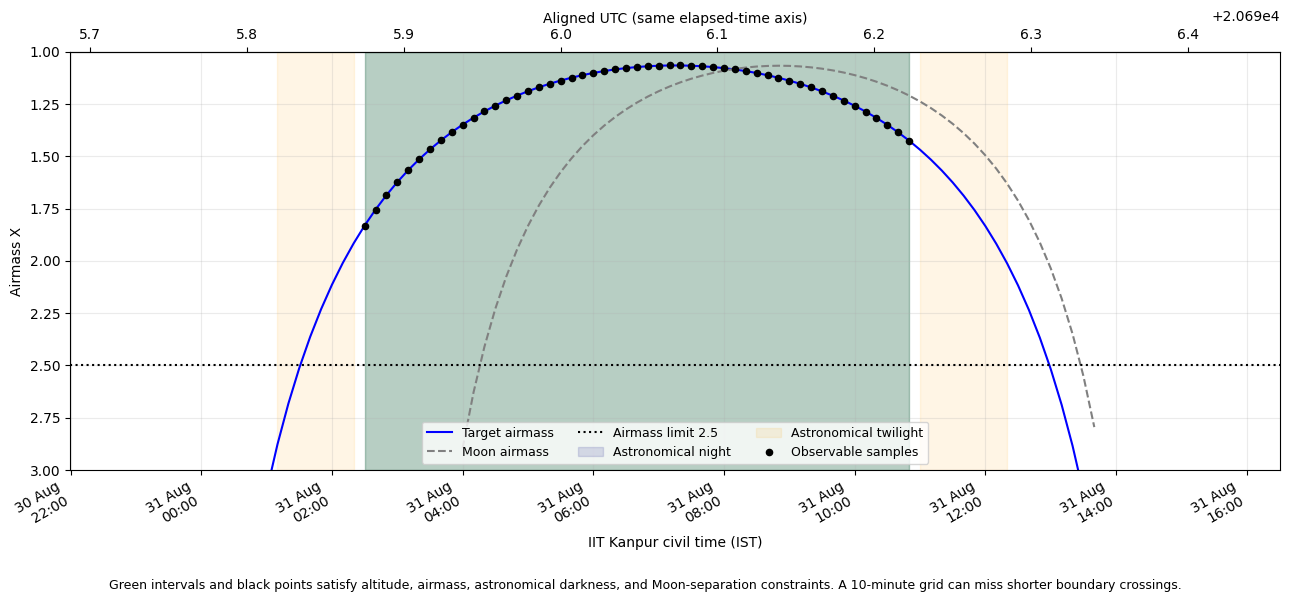

Saved: assignment_outputs/frb_20220912a_gtc_airmass.png exists: True size: 181183
Scientific conclusion: The FRB has observable sampled intervals at GTC.
Limitation: the 10-minute sampling makes interval boundaries approximate and can miss short windows.


In [46]:
# Q18
def stitch_windows(times, visibility_state):
    times = Time(times)
    state = np.asarray(visibility_state, dtype=bool)
    if times.ndim != 1 or state.ndim != 1 or len(times) != len(state):
        raise ValueError("times and visibility_state must be equal-length one-dimensional arrays.")
    windows = []
    start = None
    for i, flag in enumerate(state):
        if flag and start is None:
            start = i
        if start is not None and ((not flag) or i == len(state)-1):
            end = i if flag and i == len(state)-1 else i-1
            windows.append((start, end))
            start = None
    return windows

windows = stitch_windows(times, preferred_visibility)
print("Observable intervals:", len(windows))
for start_i, end_i in windows:
    midpoint_i = (start_i + end_i)//2
    duration = (end_i-start_i)*STEP_MINUTES*u.min
    segment_best = np.nanmin(target_airmass[start_i:end_i+1])
    print("\nUTC:", format_utc(times[start_i]), "to", format_utc(times[end_i]))
    print("IST:", format_iitk(times[start_i]), "to", format_iitk(times[end_i]))
    print("Sample-centre duration:", duration)
    print("Best target airmass:", segment_best)
    print("Midpoint Moon label:", moon_labels[midpoint_i])

# Figure
fig, ax = plt.subplots(figsize=(13,6))
dt_ist = [t.to_datetime(timezone=IITK_TIMEZONE) for t in times]
ax.plot(dt_ist, target_airmass, color="blue", label="Target airmass")
ax.plot(dt_ist, moon_airmass, "--", color="gray", label="Moon airmass")
ax.axhline(MAX_AIRMASS, color="black", linestyle=":", label="Airmass limit 2.5")
ax.fill_between(dt_ist, 1, 3, where=(sun_altitude.deg <= -18), alpha=0.12, color="navy", label="Astronomical night")
ax.fill_between(dt_ist, 1, 3, where=((sun_altitude.deg > -18)&(sun_altitude.deg <= 0)), alpha=0.10, color="orange", label="Astronomical twilight")
for start_i, end_i in windows:
    ax.axvspan(dt_ist[start_i], dt_ist[end_i], alpha=0.18, color="green")
ax.scatter(np.array(dt_ist)[preferred_visibility], target_airmass[preferred_visibility], color="black", s=20, zorder=5, label="Observable samples")
ax.set_ylim(3,1)
ax.set_ylabel("Airmass X")
ax.set_xlabel("IIT Kanpur civil time (IST)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M", tz=IITK_TIMEZONE))
ax.grid(alpha=0.25)
ax.legend(ncol=3, fontsize=9)

secax = ax.secondary_xaxis("top")
secax.set_xlabel("Aligned UTC (same elapsed-time axis)")
fig.autofmt_xdate()
fig.text(0.5, 0.01, "Green intervals and black points satisfy altitude, airmass, astronomical darkness, and Moon-separation constraints. A 10-minute grid can miss shorter boundary crossings.", ha="center", fontsize=9)
fig.tight_layout(rect=[0,0.05,1,1])
figure_path = OUTPUT_DIR/"frb_20220912a_gtc_airmass.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", figure_path, "exists:", figure_path.exists(), "size:", figure_path.stat().st_size if figure_path.exists() else 0)
print("Scientific conclusion:", "The FRB has observable sampled intervals at GTC." if windows else "No sampled time satisfies all four constraints.")
print("Limitation: the 10-minute sampling makes interval boundaries approximate and can miss short windows.")

# Part F. All-sky observability (2 assessed marks + 2 optional bonus marks)

The previous parts established the physical ingredients needed for an observing decision. The next questions reuse those same ideas at increasing scale: first one source on one date, then a weekly all-sky GTC visibility animation over one year.

For Q19–Q20, use the geometric/airmass GTC visibility rule developed in the notebook: the source or sky position must be above the horizon, satisfy the GTC airmass limit, and be inside astronomical night. Do not include the Moon in these questions.


## Q19. Find the GTC visibility window of the repeating FRB on one date [2 marks]

Treat FRB 20220912A as a repeating source at its fixed ICRS/J2000 position. For `2026-09-01`, calculate its visibility from GTC across the full UTC day using the same HEALPix-style visibility logic: astronomical night, target altitude above the horizon, and target airmass no larger than 2.5. Report the start and end of each contiguous visibility interval in UTC and IIT Kanpur time, together with the total visible duration in hours.

This is a **single source**, not an all-sky calculation.


In [47]:
# Q19
q19_start = Time("2026-09-01T00:00:00Z", scale="utc")
q19_times = q19_start + np.arange(145)*10*u.min  # inclusive full UTC day
q19_altaz = frb_icrs.transform_to(AltAz(obstime=q19_times, location=gtc_location, pressure=0*u.hPa))
q19_airmass = np.asarray(q19_altaz.secz.value, dtype=float)
q19_airmass[(q19_altaz.alt <= 0*u.deg) | (~np.isfinite(q19_airmass)) | (q19_airmass < 1)] = np.nan
q19_sun_alt = get_sun(q19_times).transform_to(AltAz(obstime=q19_times, location=gtc_location, pressure=0*u.hPa)).alt
q19_visible = ((q19_altaz.alt.deg > 0) & np.isfinite(q19_airmass) & (q19_airmass <= 2.5) & (q19_sun_alt.deg <= -18))

q19_windows = stitch_windows(q19_times, q19_visible)
total_duration = sum((e-s)*10 for s,e in q19_windows)*u.min
for s,e in q19_windows:
    print("UTC:", format_utc(q19_times[s]), "to", format_utc(q19_times[e]))
    print("IST:", format_iitk(q19_times[s]), "to", format_iitk(q19_times[e]))
print("Total visible sample-centre duration:", total_duration.to(u.hour))
print("Note: interval endpoints are limited by the 10-minute sampling grid.")

UTC: 2026-09-01 00:00:00 UTC to 2026-09-01 05:20:00 UTC
IST: 2026-09-01 05:30:00 IST to 2026-09-01 10:50:00 IST
UTC: 2026-09-01 21:00:00 UTC to 2026-09-02 00:00:00 UTC
IST: 2026-09-02 02:30:00 IST to 2026-09-02 05:30:00 IST
Total visible sample-centre duration: 8.333333333333334 h
Note: interval endpoints are limited by the 10-minute sampling grid.


## Q20. Generate a one-year GTC visibility animation [2 bonus marks]

Use the same **all-sky GTC visibility** model over the next year, starting on **2026-08-30** and sampled every 7 days. With a weekly cadence, the final sample within the 365-day window is **2027-08-29**. For each date, compute the HEALPix visibility map using the same GTC astronomical-night, altitude, and airmass conditions developed earlier.

Save each weekly map as a PNG frame and combine the frames into a GIF. The animation should show how the observable sky from GTC changes through the year. Use a moderate HEALPix resolution so that the calculation is practical.

Briefly describe what changes across the animation and why the observable region changes with date.

In [48]:
# Q20 (Bonus)
# Weekly all-sky geometric/airmass/night animation using a moderate HEALPix resolution.
import imageio.v2 as imageio

nside = 16
npix = hp.nside2npix(nside)
theta, lon = hp.pix2ang(nside, np.arange(npix))
lat = np.pi/2 - theta

weekly_dates = Time("2026-08-30T00:00:00Z") + np.arange(0, 365, 7)*u.day
frames_dir = OUTPUT_DIR/"q20_frames"
frames_dir.mkdir(exist_ok=True)
frame_paths = []

# Build all ICRS directions once.
sky = SkyCoord(ra=(lon*u.rad), dec=(lat*u.rad), frame="icrs")

for k, date in enumerate(weekly_dates):
    # Representative UTC instant for each weekly date.
    frame = AltAz(obstime=date, location=gtc_location, pressure=0*u.hPa)
    altaz = sky.transform_to(frame)
    secz = np.asarray(altaz.secz.value, dtype=float)
    sun_alt = get_sun(date).transform_to(frame).alt.deg
    visible = ((altaz.alt.deg > 0) & np.isfinite(secz) & (secz >= 1) & (secz <= 2.5) & (sun_alt <= -18))
    vis_map = visible.astype(float)

    fig = plt.figure(figsize=(9,5))
    hp.mollview(vis_map, fig=fig.number, title=f"GTC all-sky visibility: {date.utc.isot[:10]}", unit="Visible (1=yes)", min=0, max=1, cmap="viridis")
    path = frames_dir/f"frame_{k:03d}.png"
    plt.savefig(path, dpi=120, bbox_inches="tight")
    plt.close(fig)
    frame_paths.append(path)

gif_path = OUTPUT_DIR/"gtc_visibility_one_year.gif"
with imageio.get_writer(gif_path, mode="I", duration=0.25, loop=0) as writer:
    for path in frame_paths:
        writer.append_data(imageio.imread(path))

print("Frames:", len(frame_paths))
print("GIF saved:", gif_path, "exists:", gif_path.exists())
print("Description: the visible region changes with date because Earth's orbital motion changes which right ascensions are in the nighttime sky, while GTC latitude and the altitude/airmass limits determine the accessible declination geometry.")

/usr/local/lib/python3.13/dist-packages/healpy/visufunc.py:225: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


Frames: 53
GIF saved: assignment_outputs/gtc_visibility_one_year.gif exists: True
Description: the visible region changes with date because Earth's orbital motion changes which right ascensions are in the nighttime sky, while GTC latitude and the altitude/airmass limits determine the accessible declination geometry.


## Submission checklist

- Restart the kernel and run every cell from top to bottom.
- Keep units attached during physical calculations.
- Use UTC internally; show IIT Kanpur time whenever reporting a civil clock time.
- Label Local Sidereal Time as LST, never IST.
- Keep the exact `visibility(altitude, airmass, sun_altitude, moon_separation)` interface.
- Confirm `assignment_outputs/frb_20220912a_gtc_airmass.png` exists and is non-empty.
- Confirm the Q20 one-year GTC GIF and its generated weekly frame PNGs are present.

## Compact glossary

- **Astropy quantity:** a numerical value stored together with a physical unit.
- **UTC:** the standard time scale used to identify an instant worldwide.
- **IST:** Indian Standard Time, the IIT Kanpur civil clock, UTC+05:30.
- **JD/MJD:** continuous astronomical day counts; MJD is JD minus 2,400,000.5.
- **ICRS:** a modern standard equatorial frame expressed with RA and Dec.
- **Galactic coordinates:** longitude $l$ and latitude $b$ referred to the Milky Way.
- **Ecliptic coordinates:** longitude $\lambda$ and latitude $\beta$ referred to Earth's orbital plane; longitude begins at the vernal equinox.
- **Angular separation:** the shortest great-circle angle between two directions on the celestial sphere.
- **Mollweide projection:** an equal-area elliptical map of the full celestial sphere; Matplotlib expects longitude and latitude in radians.
- **LST:** Local Sidereal Time, an astronomical angle determined by time and longitude.
- **Hour angle:** $H=\mathrm{LST}-\alpha$; zero at meridian transit.
- **Transit:** passage across the local meridian; usually the highest geometric altitude.
- **AltAz:** a horizon frame determined by observer location and time.
- **Zenith distance:** angular distance from the zenith, $z=90^\circ-h$.
- **Airmass:** approximate atmospheric path length relative to the zenith.
- **Astronomical darkness:** Sun altitude at or below $-18^\circ$ in this assignment.
- **Observable interval:** consecutive samples satisfying every printed condition.

- **HEALPix:** a hierarchical equal-area pixelization of the celestial sphere; each pixel can store an astronomical quantity such as visibility time.
- **Visibility time:** the amount of time a source satisfies the observing constraints during a specified interval.
- **Repeating FRB:** an FRB that can produce bursts on multiple occasions, so a future observing schedule can be planned for its fixed sky position.
